In [30]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time

INFO: Using numpy backend


In [29]:
np.sqrt(2)*2*(np.random.beta(1/2, 1/2, size = 10000) - 1/2).mean()

0.007301692214866983

In [18]:
file = '/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_euc/data/euc_samp1_N50_sigma0.6.pkl'
infile=open(file, 'rb')
result=np.load(infile, allow_pickle=True)
print(result)
infile.close()

{'X': array([[ 1.32926815,  1.2560583 , -1.38481037],
       [-1.21270459, -1.21006828,  0.91179671],
       [ 1.38965828, -1.41175225, -0.8834871 ],
       [ 1.38784327,  0.44211083, -1.36000792],
       [ 0.76662616,  0.71958945,  1.30018209],
       [ 1.40924491,  0.52115322, -1.35686904],
       [ 1.39638954, -1.38416311,  0.82026889],
       [ 1.17130491, -0.12063101,  1.1635999 ],
       [ 0.62050441,  0.43851941, -0.09939332],
       [ 0.42305096,  1.36914353, -0.35715618],
       [-0.03083156,  0.08438674,  0.53598377],
       [ 1.40156007, -1.10636982, -1.05964238],
       [-0.77045795,  1.04666681,  0.47091973],
       [ 0.76023989,  1.39334316, -1.38490215],
       [-1.39685058,  0.1990049 ,  1.31801038],
       [ 0.16202593,  0.09324248,  1.12700239],
       [-1.40248672, -0.65732332,  0.31822818],
       [-0.80379789, -0.31992438,  1.03994467],
       [-0.94488088,  1.36773773, -1.25362053],
       [-0.95519137,  1.41417954,  0.18733383],
       [ 0.33855044,  1.41088277, 

In [19]:
file = '/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_euc/data/euc_samp1_N100_sigma0.6.pkl'
infile=open(file, 'rb')
result=np.load(infile, allow_pickle=True)
print(result)
infile.close()

{'X': array([[-0.08690874, -1.33992835,  1.40024672],
       [ 0.36343371,  0.00144681,  1.41413045],
       [ 0.8124578 , -0.52378304, -0.49900424],
       [-1.01652503, -1.32681261, -0.35052322],
       [ 1.2667015 , -1.39430681,  1.3953218 ],
       [-1.26846853,  0.28140806,  0.08480454],
       [-1.09493421,  1.409992  ,  0.88719718],
       [-0.67987822, -0.94484255, -0.03089973],
       [-0.29909529,  1.27926646,  1.41124977],
       [ 1.39300844,  1.40744354,  1.2316223 ],
       [-0.17249009,  1.06279104, -1.08287881],
       [-1.41323032, -1.35100806,  1.0893313 ],
       [-1.20850476,  1.01954193, -0.40608748],
       [-0.5658942 , -0.29555683,  0.34574427],
       [-1.36123616,  1.41351005,  0.42453902],
       [ 0.93263949, -1.21161493,  1.27290519],
       [ 0.90811968,  1.10123098, -1.41004683],
       [-0.70819274, -1.12591899, -0.21469557],
       [ 1.20862023, -1.37171919, -0.34817536],
       [-1.23324073,  1.34689807,  0.01369561],
       [-0.80605949, -1.26733662, 

## Functions

In [2]:
def pb_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'sigma', 'OOB_quantile', 'forest', 'time'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'results')):
        if file.endswith('.npy'):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        start_time = time.time()
        oob_quantile = np.percentile(np.abs(result['forest'].oob_prediction_ - result['y_data']), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')
        end_time = time.time()
        time_oob = end_time - start_time
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'sigma': file.split('_')[3][5:],
            'forest': [result['forest']],
            'OOB_quantile': [oob_quantile],
            'time': [result['tuning_fitting_time'] + time_oob],
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['sigma'] = coverage_df.sigma.astype('category')
    return coverage_df

### SPLIT-CONFORMAL

def conf_coverage_results():
    """ Compute empirical quantiles for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'sigma', 'forest', 'time'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conformal_results')):
        if file.endswith('.npy'):
            i+=1
            print(i)
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conformal_results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        sample_index = int(file.split('_')[1][4:])
        train_size = int(file.split('_')[2][1:])
        sigma = file.split('_')[3][5:]

        start_time = time.time()
        test_preds = result['forest'].predict(result['x_test_data'])
        quantile = np.percentile(np.abs(result['y_test_data'] -  test_preds), (1 - np.array([0.01, 0.05, 0.1])) * 100, method='inverted_cdf')
        end_time = time.time()
        time_conf = end_time - start_time
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'x_test_data': [result['x_test_data']],
            'sample_index': sample_index,
            'train_size': train_size,
            'sigma': sigma,
            'forest': [result['forest']],
            'quantiles': [quantile],
            'time': [result['tuning_fitting_time'] + time_conf],
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['sigma'] = coverage_df.sigma.astype('category')
    return coverage_df


# Function to simulate regression data
def simulate_data(sigma, X_design, betas):
    Ys = []
    sample_size = X_design.shape[0]

    # Generate the error term epsilon, which follows a normal distribution
    epsilon = np.random.normal(0, sigma, size = sample_size).reshape(sample_size, 1)

    # Step 2: Apply the model transformations
    X_1 = X_design[:, 0]  # X_1 corresponds to the first column (without intercept)
    X_2 = X_design[:, 1]  # X_2 corresponds to the second column
    X_3 = X_design[:, 2]  # X_3 corresponds to the third column

    # Calculate the response vector Y = beta_0 + beta_1*X_1 + beta_2*X_2 + beta_3*X_3 + epsilon
    Ys = betas[0] * X_1 + betas[1] * X_2 + betas[2] * X_3
    # Convert list to array for easier manipulation
    Ys = Ys.reshape(sample_size, 1) + epsilon
    
    return X_design, Ys

### Read the data

Prediction balls

In [4]:
# Define confidence levels
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
betas = np.array([1, -1, 1])  # Define the true beta values
# Load stored results
pb_coverage_df=pb_coverage_results()
pb_coverage_df.head()

0


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_81544/597303596.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  coverage_df = pd.concat([coverage_df, pd.DataFrame({


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


,sample_index,train_size,sigma,OOB_quantile,forest,time
0,339,50,1.7,"[3.416533034076581, 3.2719381814930615, 2.5680...","(DecisionTreeRegressor(max_features=2, min_sam...",4.293078
1,488,500,0.9,"[2.5372353482505803, 1.8151184960852569, 1.609...","(DecisionTreeRegressor(max_features=2, min_sam...",6.378329
2,27,500,0.6,"[1.6569351439051019, 1.235931437887241, 0.9875...","(DecisionTreeRegressor(max_features=2, random_...",6.424804
3,82,100,0.6,"[1.8535769187546625, 1.4763841321048943, 1.216...","(DecisionTreeRegressor(max_features=3, random_...",4.708149
4,455,200,0.9,"[2.5353885416818858, 1.9270336027030706, 1.613...","(DecisionTreeRegressor(max_features=2, min_sam...",5.091071


Split_Conformal

In [5]:
# Define confidence levels
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
conformal_coverage_df=conf_coverage_results()
conformal_coverage_df.head()

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_81544/597303596.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  coverage_df = pd.concat([coverage_df, pd.DataFrame({


31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
2

,sample_index,train_size,sigma,forest,time,x_test_data,quantiles
0,339,50,1.7,"(DecisionTreeRegressor(max_features=2, random_...",4.343688,"[[-0.09309465359866426, -0.4078574187756428, 0...","[3.8090170967543164, 3.5047659422440427, 3.003..."
1,488,500,0.9,"(DecisionTreeRegressor(max_features=3, min_sam...",5.295800,"[[0.5413650944561323, 0.5532088779882177, 0.34...","[2.7180059204834945, 1.8473518040587442, 1.622..."
2,27,500,0.6,"(DecisionTreeRegressor(max_features=2, random_...",5.400498,"[[1.2927667942165173, 1.3095441450899923, -1.4...","[1.7665605078309818, 1.2053814183438494, 1.040..."
3,82,100,0.6,"(DecisionTreeRegressor(max_features=3, random_...",4.576832,"[[1.177998795430376, -1.3117707714790274, 1.32...","[2.1684101812687073, 1.5653649499417075, 1.128..."
4,455,200,0.9,"(DecisionTreeRegressor(max_features=1, random_...",4.678936,"[[1.3510438509862233, -1.354302096775215, 1.33...","[2.248093859882377, 2.0139712507980345, 1.3461..."


# TYPE I

In [5]:
sigmas = np.array([0.6, 0.9, 1.7])
MC = 500
n_estimations = 50
n_predictors = 3

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

i_pb_diccionario = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

i_conf_diccionario = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

In [15]:
# Obtain n_estimations estimations of Type I coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for sigma in [0.6, 0.9, 1.7]:

    pb_coverage_df_sigma = pb_coverage_df[pb_coverage_df['sigma'] == str(sigma)]
    conformal_coverage_df_sigma = conformal_coverage_df[conformal_coverage_df['sigma'] == str(sigma)]

    if sigma == 0.6:
        true_sigma = 1/np.sqrt(3)
    elif sigma == 0.9:
        true_sigma = np.sqrt(3)/2
    elif sigma == 1.7:
        true_sigma = np.sqrt(3)
    else:
        raise ValueError("Sigma value not found.")

    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = pb_coverage_df_sigma[pb_coverage_df_sigma['train_size'] == N]
        conf_coverage_df_N = conformal_coverage_df_sigma[conformal_coverage_df_sigma['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)
            conf_yesno = np.zeros(3)
            # Randomly select rows from the dataframe
            new_X_design = np.sqrt(2)*2*(np.random.beta(1/2, 1/2, (MC, n_predictors)) - 1/2)
            # Add a column of ones for the intercept (beta_0)
            new_X_design, new_ys = simulate_data(sigma = true_sigma, X_design=new_X_design, betas=betas)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
            conf_lns = conf_coverage_df_N.sample(n=MC, replace=False)
    
            i = 0
            for j, pb_ln in pb_lns.iterrows():
                conf_ln = conf_lns.iloc[i]
                # Generate one random point to test if it belongs to the CI_region
                new_X = new_X_design[i,:].reshape(1, n_predictors)

                #Predict the new observation
                pb_new_pred = pb_ln['forest'].predict(new_X)
                conf_new_pred = conf_ln['forest'].predict(new_X)

                new_y = new_ys[i]

                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, np.abs(pb_new_pred - new_y) <= pb_ln['OOB_quantile']))
                conf_yesno = np.vstack((conf_yesno, np.abs(conf_new_pred - new_y) <= conf_ln['quantiles']))

                i += 1

            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC
            conf_cov[estimation, :] = conf_yesno[1:,:].sum(axis=0) / MC
            
        i_pb_diccionario['sigma_'+str(sigma)][str(N)] = np.copy(pb_cov)
        
        i_conf_diccionario['sigma_'+str(sigma)][str(N)] = np.copy(conf_cov)

In [16]:
for sigma in [0.6, 0.9, 1.7]:    
        for N in [50, 100, 200, 500]:
            print(f"sigma = {sigma}, N = {N}, mean of Type I coverage estimates: ", np.mean(i_pb_diccionario['sigma_'+str(sigma)][str(N)], axis = 0)) 
            print(f"sigma = {sigma}, N = {N}, standard deviation of Type I coverage estimates: ", np.sqrt(np.var(i_pb_diccionario['sigma_'+str(sigma)][str(N)], axis = 0))  )    

sigma = 0.6, N = 50, mean of Type I coverage estimates:  [0.98424 0.949   0.89544]
sigma = 0.6, N = 50, standard deviation of Type I coverage estimates:  [0.00606155 0.01037111 0.01517914]
sigma = 0.6, N = 100, mean of Type I coverage estimates:  [0.98056 0.94092 0.8906 ]
sigma = 0.6, N = 100, standard deviation of Type I coverage estimates:  [0.00647506 0.01086064 0.01201499]
sigma = 0.6, N = 200, mean of Type I coverage estimates:  [0.986   0.94724 0.89616]
sigma = 0.6, N = 200, standard deviation of Type I coverage estimates:  [0.0045607  0.00819649 0.01267337]
sigma = 0.6, N = 500, mean of Type I coverage estimates:  [0.98944 0.94956 0.89764]
sigma = 0.6, N = 500, standard deviation of Type I coverage estimates:  [0.0038375  0.00922856 0.01425308]
sigma = 0.9, N = 50, mean of Type I coverage estimates:  [0.98144 0.9452  0.88324]
sigma = 0.9, N = 50, standard deviation of Type I coverage estimates:  [0.00594697 0.01052236 0.01478318]
sigma = 0.9, N = 100, mean of Type I coverage est

Prediction balls

In [17]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(i_pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(i_pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
df

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.6   50            98.42 (0.61)  94.90 (1.04)  89.54 (1.52)
      100           98.06 (0.65)  94.09 (1.09)  89.06 (1.20)
      200           98.60 (0.46)  94.72 (0.82)  89.62 (1.27)
      500           98.94 (0.38)  94.96 (0.92)  89.76 (1.43)
0.9   50            98.14 (0.59)  94.52 (1.05)  88.32 (1.48)
      100           98.00 (0.70)  94.34 (0.98)  89.52 (1.34)
      200           98.47 (0.53)  94.53 (1.03)  89.42 (1.14)
      500           98.74 (0.57)  94.67 (1.14)  89.67 (1.53)
1.7   50            97.70 (0.71)  93.47 (1.13)  87.29 (1.43)
      100           98.06 (0.61)  93.89 (1.10)  88.76 (1.59)
      200           98.51 (0.45)  94.52 (0.99)  89.78 (1.36)
      500           98.80 (0.44)  94.91 (0.70)  90.24 (1.24)

In [18]:
import pandas as pd
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Apply formatting to all cells
df = df.applymap(format_cell)

latex = df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:typeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56630/2912561022.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(format_cell)


In [19]:
print(latex)

\begin{table}
\caption{Type I error}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.6}} & \textbf{50} & 98.42 (0.61) & 94.90 (1.04) & 89.54 (1.52) \\
\textbf{} & \textbf{100} & 98.06 (0.65) & 94.09 (1.09) & 89.06 (1.20) \\
\textbf{} & \textbf{200} & 98.60 (0.46) & 94.72 (0.82) & 89.62 (1.27) \\
\textbf{} & \textbf{500} & 98.94 (0.38) & 94.96 (0.92) & 89.76 (1.43) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.9}} & \textbf{50} & 98.14 (0.59) & 94.52 (1.05) & 88.32 (1.48) \\
\textbf{} & \textbf{100} & 98.00 (0.70) & 94.34 (0.98) & 89.52 (1.34) \\
\textbf{} & \textbf{200} & 98.47 (0.53) & 94.53 (1.03) & 89.42 (1.14) \\
\textbf{} & \textbf{500} & 98.74 (0.57) & 94.67 (1.14) & 89.67 (1.53) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.7}} & \textbf{50} & 97.70 (0.71) & 93.47 (1.13) & 87.29 (1.43) \\
\textbf{} & \textbf{100} & 98.06 (0.61) & 93.89 (1.10) & 88.76

SC

In [20]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(i_conf_diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(i_conf_diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
conf_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
conf_df

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.6   50            96.40 (0.82)  93.03 (1.12)  89.55 (1.28)
      100           98.19 (0.51)  94.06 (1.07)  88.14 (1.56)
      200           97.90 (0.66)  94.12 (1.03)  89.42 (1.49)
      500           98.72 (0.52)  94.62 (0.98)  89.42 (1.42)
0.9   50            96.39 (0.85)  92.24 (1.24)  88.61 (1.63)
      100           97.95 (0.58)  94.07 (0.97)  88.39 (1.34)
      200           97.97 (0.55)  93.85 (0.96)  88.99 (1.47)
      500           98.72 (0.53)  94.63 (1.09)  89.50 (1.34)
1.7   50            96.35 (0.83)  92.84 (1.20)  89.07 (1.62)
      100           98.07 (0.59)  94.26 (0.99)  88.29 (1.15)
      200           98.11 (0.58)  94.06 (1.11)  89.13 (1.33)
      500           98.84 (0.53)  94.68 (1.19)  89.18 (1.45)

In [21]:
conf_latex = conf_df.applymap(format_cell)

conf_latex = conf_latex.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error coverage for different distances, degrees of freedom and sample sizes', label='tab:typeIerrorcoverage')
print(conf_latex)

\begin{table}
\caption{Type I error coverage for different distances, degrees of freedom and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.6}} & \textbf{50} & 96.40 (0.82) & 93.03 (1.12) & 89.55 (1.28) \\
\textbf{} & \textbf{100} & 98.19 (0.51) & 94.06 (1.07) & 88.14 (1.56) \\
\textbf{} & \textbf{200} & 97.90 (0.66) & 94.12 (1.03) & 89.42 (1.49) \\
\textbf{} & \textbf{500} & 98.72 (0.52) & 94.62 (0.98) & 89.42 (1.42) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.9}} & \textbf{50} & 96.39 (0.85) & 92.24 (1.24) & 88.61 (1.63) \\
\textbf{} & \textbf{100} & 97.95 (0.58) & 94.07 (0.97) & 88.39 (1.34) \\
\textbf{} & \textbf{200} & 97.97 (0.55) & 93.85 (0.96) & 88.99 (1.47) \\
\textbf{} & \textbf{500} & 98.72 (0.53) & 94.63 (1.09) & 89.50 (1.34) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.7}} & \textbf{50} & 96.35 (0.83) & 92.84 (1.20) & 89.07 (1

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56630/2342737267.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  conf_latex = conf_df.applymap(format_cell)


Combined

In [69]:
import pandas as pd
import numpy as np

def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        row = []
        means_pb = np.mean(i_pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds_pb = np.sqrt(np.var(i_pb_diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        
        means_conf = np.mean(i_conf_diccionario[f'sigma_{sigma}'][str(N)], axis=0)
        stds_conf = np.sqrt(np.var(i_conf_diccionario[f'sigma_{sigma}'][str(N)], axis=0))
        
        # Format as "mean (std)"
        formatted_values_pb = [f"{100*means_pb[i]:.2f} ({100*stds_pb[i]:.2f})" for i in range(3)]
        formatted_values_conf = [f"{100*means_conf[i]:.2f} ({100*stds_conf[i]:.2f})" for i in range(3)]
        
        row.extend(formatted_values_pb + formatted_values_conf)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=[f"$\sigma$", f"$n$"])
col_index = pd.MultiIndex.from_product(
    [["Prediction Balls", "Split-Conformal"], ["0.01", "0.05", "0.1"]],
    names=["", ""]
)

# Create the DataFrame
df_combined = pd.DataFrame(rows, index=row_index, columns=col_index)

# Apply formatting
df_combined = df_combined.applymap(format_cell)

# Convert to LaTeX
latex_combined = df_combined.to_latex(index=True, multirow=True, multicolumn=True, 
                                      multicolumn_format='c', bold_rows=False, 
                                      float_format="%.3f", 
                                      caption='Comparison of Type I error coverage for prediction balls and SC regions', 
                                      label='tab:euc_typeI_PB_SC')

print(latex_combined)


\begin{table}
\caption{Comparison of Type I error coverage for prediction balls and SC regions}
\label{tab:euc_typeI_PB_SC}
\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{3}{c}{Prediction Balls} & \multicolumn{3}{c}{Split-Conformal} \\
 &  & 0.01 & 0.05 & 0.1 & 0.01 & 0.05 & 0.1 \\
$\sigma$ & $n$ &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{0.6} & 50 & 98.42 (0.61) & 94.90 (1.04) & 89.54 (1.52) & 96.40 (0.82) & 93.03 (1.12) & 89.55 (1.28) \\
 & 100 & 98.06 (0.65) & 94.09 (1.09) & 89.06 (1.20) & 98.19 (0.51) & 94.06 (1.07) & 88.14 (1.56) \\
 & 200 & 98.60 (0.46) & 94.72 (0.82) & 89.62 (1.27) & 97.90 (0.66) & 94.12 (1.03) & 89.42 (1.49) \\
 & 500 & 98.94 (0.38) & 94.96 (0.92) & 89.76 (1.43) & 98.72 (0.52) & 94.62 (0.98) & 89.42 (1.42) \\
\cline{1-8}
\multirow[t]{4}{*}{0.9} & 50 & 98.14 (0.59) & 94.52 (1.05) & 88.32 (1.48) & 96.39 (0.85) & 92.24 (1.24) & 88.61 (1.63) \\
 & 100 & 98.00 (0.70) & 94.34 (0.98) & 89.52 (1.34) & 97.95 (0.58) & 94.07 (0.97) & 88.39 (1.34) \\
 & 200 & 

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56630/2946832433.py:43: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_combined = df_combined.applymap(format_cell)


# TYPE II

In [22]:
pb_coverage_df['II_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500
n_predictors = 3
np.random.seed(1000)

#Calculate coverage for every dataset L_n (Type II):
for i, ln in pb_coverage_df.iterrows():
    #Generate observations to estimate the probability
    new_X_design = np.sqrt(2)*2*(np.random.beta(1/2, 1/2, (MC, n_predictors)) - 1/2)
    if float(ln['sigma']) == 0.6:
        sigma = 1/np.sqrt(3)
    elif float(ln['sigma']) == 0.9:
        sigma = np.sqrt(3)/2
    elif float(ln['sigma']) == 1.7:
        sigma = np.sqrt(3)
    else:
        raise ValueError("Sigma value not found.")
    new_X, new_y = simulate_data(sigma = sigma, X_design=new_X_design, betas = betas)

    new_pred = ln['forest'].predict(new_X)

    pb_coverage_df.at[i, 'II_coverage'] = np.sum(np.abs(new_pred.reshape(-1,1) - new_y).reshape(-1,1) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis = 0) / MC

In [199]:
import numpy as np

# Generate the sample
sample = np.sqrt(2) * 2 * (np.random.beta(1/2, 1/2, 1000000) - 1/2)

# Compute the 0.25 quantile for each component (X1', X2', X3')
quantile_25 = np.percentile(sample, 75, axis=0)

# Output the quantiles
print("0.25 quantile of each component of X:", quantile_25)


0.25 quantile of each component of X: -1.0002658034496716


In [ ]:
np.sqrt(2)*2*(np.random.beta(1/2, 1/2, (500, 3)) - 1/2)

In [23]:
conformal_coverage_df['II_coverage'] = [[0, 0, 0] for _ in range(len(conformal_coverage_df))]
MC = 500
np.random.seed(1000)

#Calculate coverage for every dataset L_n (Type IV):
for i, ln in conformal_coverage_df.iterrows():
    #Generate observations to estimate the probability
    new_X_design = np.sqrt(2)*2*(np.random.beta(1/2, 1/2, (MC, n_predictors)) - 1/2)
    if float(ln['sigma']) == 0.6:
        sigma = 1/np.sqrt(3)
    elif float(ln['sigma']) == 0.9:
        sigma = np.sqrt(3)/2
    elif float(ln['sigma']) == 1.7:
        sigma = np.sqrt(3)
    else:
        raise ValueError("Sigma value not found.")
    new_X, new_y = simulate_data(sigma = float(ln['sigma']), X_design=new_X_design, betas = betas)

    new_pred = ln['forest'].predict(new_X)

    conformal_coverage_df.at[i, 'II_coverage'] = np.sum(np.abs(new_pred.reshape(-1,1) - new_y).reshape(-1,1) <= np.tile(ln['quantiles'], (MC, 1)), axis = 0) / MC

In [24]:
ii_pb_coverage_df_alpha_01 = pb_coverage_df.copy()
ii_pb_coverage_df_alpha_05 = pb_coverage_df.copy()
ii_pb_coverage_df_alpha_1  = pb_coverage_df.copy()

ii_pb_coverage_df_alpha_01['II_coverage'] = pb_coverage_df['II_coverage'].apply(lambda x: x[0])
ii_pb_coverage_df_alpha_01['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[0])

ii_pb_coverage_df_alpha_05['II_coverage'] = pb_coverage_df['II_coverage'].apply(lambda x: x[1])
ii_pb_coverage_df_alpha_05['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[1])

ii_pb_coverage_df_alpha_1['II_coverage'] = pb_coverage_df['II_coverage'].apply(lambda x: x[2])
ii_pb_coverage_df_alpha_1['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_alpha_01.head()
ii_pb_coverage_df_alpha_05.head()
ii_pb_coverage_df_alpha_1.head()

ii_coverage_df_conformal_alpha_01 = conformal_coverage_df.copy()
ii_coverage_df_conformal_alpha_05 = conformal_coverage_df.copy()
ii_coverage_df_conformal_alpha_1 =  conformal_coverage_df.copy()

ii_coverage_df_conformal_alpha_01['II_coverage'] = conformal_coverage_df['II_coverage'].apply(lambda x: x[0])
ii_coverage_df_conformal_alpha_01['quantiles'] = conformal_coverage_df['quantiles'].apply(lambda x: x[0])

ii_coverage_df_conformal_alpha_05['II_coverage'] = conformal_coverage_df['II_coverage'].apply(lambda x: x[1])
ii_coverage_df_conformal_alpha_05['quantiles'] = conformal_coverage_df['quantiles'].apply(lambda x: x[1])

ii_coverage_df_conformal_alpha_1['II_coverage'] = conformal_coverage_df['II_coverage'].apply(lambda x: x[2])
ii_coverage_df_conformal_alpha_1['quantiles'] = conformal_coverage_df['quantiles'].apply(lambda x: x[2])

ii_coverage_df_conformal_alpha_01.head()
ii_coverage_df_conformal_alpha_05.head()
ii_coverage_df_conformal_alpha_1.head()

,sample_index,train_size,sigma,forest,time,x_test_data,quantiles,II_coverage
0,339,50,1.7,"(DecisionTreeRegressor(max_features=2, random_...",5.365662,"[[-0.09309465359866426, -0.4078574187756428, 0...",3.003542,0.904
1,488,500,0.9,"(DecisionTreeRegressor(max_features=3, min_sam...",5.300507,"[[0.5413650944561323, 0.5532088779882177, 0.34...",1.622036,0.888
2,27,500,0.6,"(DecisionTreeRegressor(max_features=2, random_...",5.540146,"[[1.2927667942165173, 1.3095441450899923, -1.4...",1.040910,0.870
3,82,100,0.6,"(DecisionTreeRegressor(max_features=3, random_...",4.633087,"[[1.177998795430376, -1.3117707714790274, 1.32...",1.128140,0.800
4,455,200,0.9,"(DecisionTreeRegressor(max_features=1, random_...",5.517519,"[[1.3510438509862233, -1.354302096775215, 1.33...",1.346128,0.822


In [25]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip([ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], 
                             [ii_coverage_df_conformal_alpha_01, ii_coverage_df_conformal_alpha_05, ii_coverage_df_conformal_alpha_1],
                             [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    data_50 = data[data['train_size'] == 50]
    data_100 = data[data['train_size'] == 100]
    data_200 = data[data['train_size'] == 200]
    data_1500 = data[data['train_size'] == 500]

    boxplot_data = pd.DataFrame({
        '50': data_50['II_coverage'].values,
        '100': data_100['II_coverage'].values,
        '200': data_200['II_coverage'].values,
        '500': data_500['II_coverage'].values
    })

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"

    #sns.boxplot(data = data, x='train_size', y='II_coverage',
               # flierprops={"marker": "x"}, dodge=True, showmeans=True, meanprops={'marker':'o','markerfacecolor':'white','markeredgecolor':'white','markersize':'4'})

    ax.boxplot(boxplot_data, labels = ['50', '100', '200', '500'], notch=False, boxprops=boxprops, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops, showmeans=False) 
    
    vals, names, xs = [],[],[]
    for i, col in enumerate(boxplot_data.columns):
        vals.append(boxplot_data[col].values)
        names.append(col)
        xs.append(np.random.normal(i + 1, 0.04, boxplot_data[col].values.shape[0]))  # adds jitter to the data points - can be adjusted
    palette = ['#ee6100', 'g', 'b', 'y']
    for x, val, c in zip(xs, vals, palette):
        ax.scatter(x, val, alpha=0.4, color=c)
    sns.despine(bottom=True) # removes right and top axis lines

    #plt.legend(bbox_to_anchor=(0.31, 1.06), loc=2, borderaxespad=0., framealpha=1, facecolor ='white', frameon=True)
    ax.set_ylim(0.7, 1)
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_euc/pb_sigma_vs_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

ValueError: too many values to unpack (expected 2)

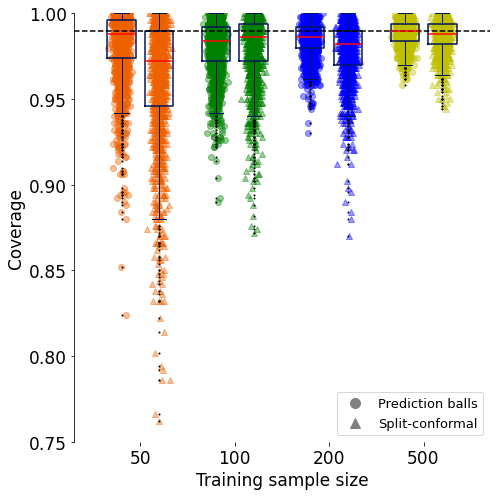

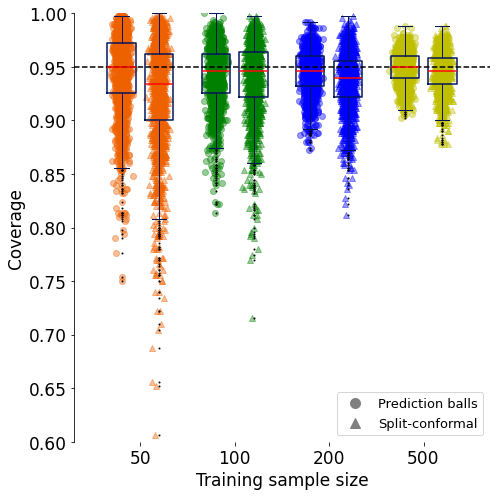

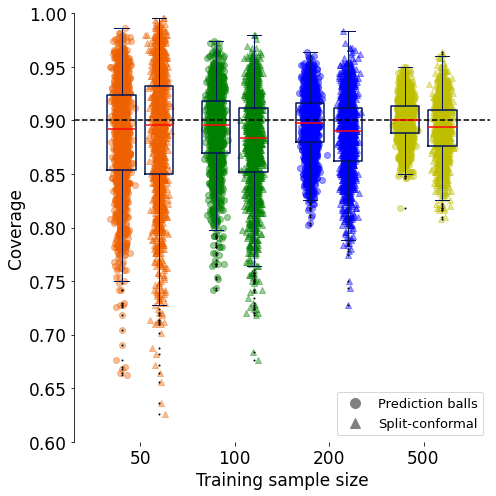

In [217]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for pb_data, conf_data, alpha_level in zip(
    [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], 
    [ii_coverage_df_conformal_alpha_01, ii_coverage_df_conformal_alpha_05, ii_coverage_df_conformal_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_boxplot_data = [pb_data[pb_data['train_size'] == size]['II_coverage'].values for size in train_sizes]
    conf_boxplot_data = [conf_data[conf_data['train_size'] == size]['II_coverage'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_pb = np.array(range(len(train_sizes))) - 0.2
    positions_conf = np.array(range(len(train_sizes))) + 0.2

#    ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
#               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
#               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
#               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
#               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
    
    ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_boxplot_data, positions=positions_conf, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_euc = ['#ee6100', 'g', 'b', 'y']
    palette_conf = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_euc = np.random.normal(positions_pb[i], 0.04, len(pb_boxplot_data[i]))
        xs_conf = np.random.normal(positions_conf[i], 0.04, len(conf_boxplot_data[i]))

        ax.scatter(xs_euc, pb_boxplot_data[i], alpha=0.4, color=palette_euc[i], label='Prediction balls')
        ax.scatter(xs_conf, conf_boxplot_data[i], alpha=0.4, color=palette_conf[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.75, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.6, 1)
    else:
        ax.set_ylim(0.6, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_vs_II_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

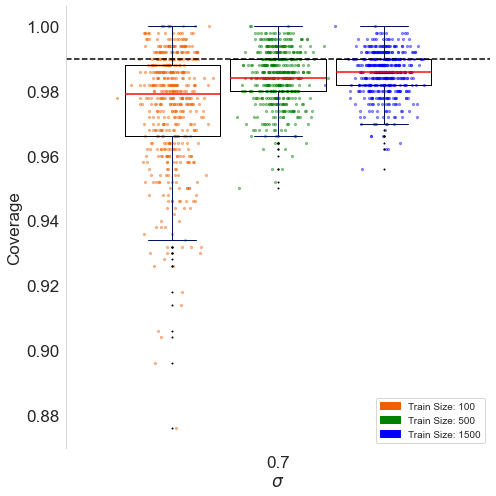

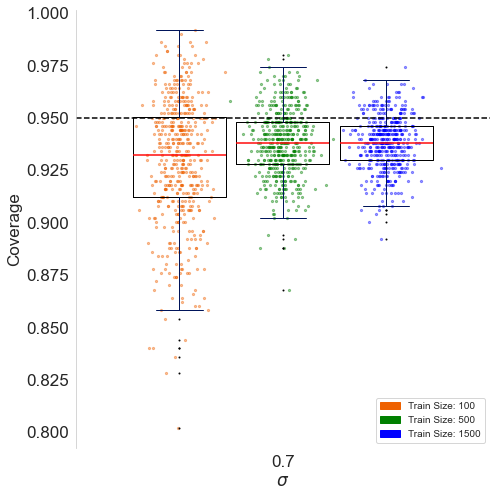

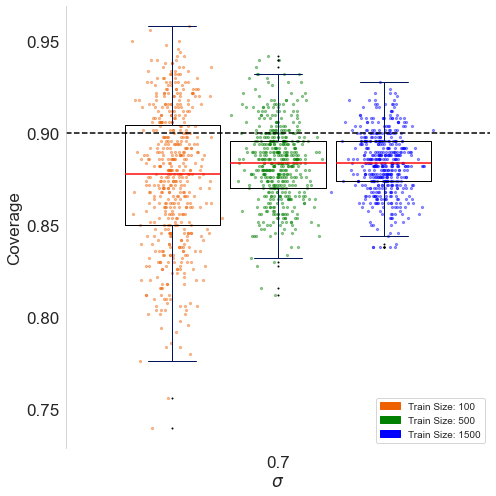

In [102]:
for data, alpha_level in zip(
    [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_pb_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_pb_coverage_df_alpha_05
    else:
        coverage_df = ii_pb_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    sigmas = sorted(coverage_df['sigma'].unique())

    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['sigma'] == sigma) & (coverage_df['train_size'] == N), 'II_coverage']
            for N in train_sizes]
        for sigma in sigmas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for a given train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.axhline(y = 1 - alpha_level, color='black', linestyle='dashed', label=f'1 - $\\alpha$')
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(sigmas))],
        labels=sigmas
    )
    ax.tick_params(labelsize=17)
    ax.set_xlim(0, len(sigmas) * (len(train_sizes) + 1))
    ax.set_xlabel(r'$\sigma$', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='lower right')
    ax.grid(False)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_euc/pb_euc_sigma_vs_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

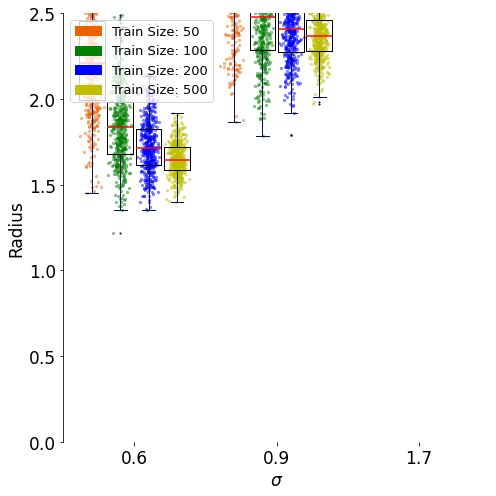

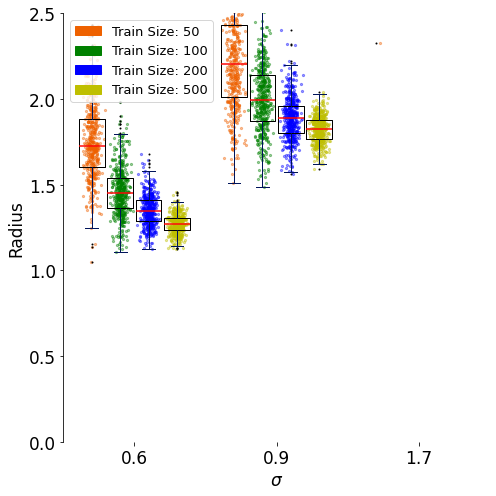

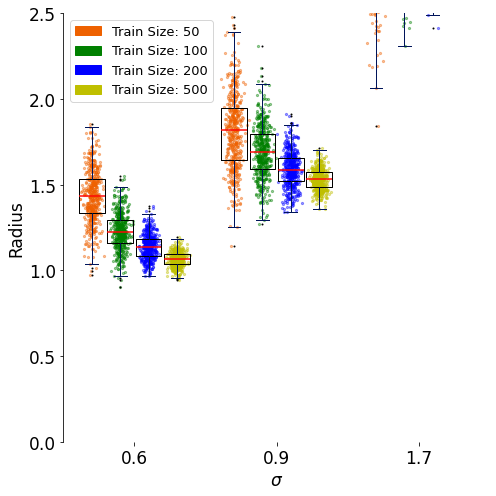

In [27]:
for data, alpha_level in zip(
    [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_pb_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_pb_coverage_df_alpha_05
    else:
        coverage_df = ii_pb_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    sigmas = sorted(coverage_df['sigma'].unique())

    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['sigma'] == sigma) & (coverage_df['train_size'] == N), 'OOB_quantile']
            for N in train_sizes]
        for sigma in sigmas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for a given train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(sigmas))],
        labels=sigmas
    )
    ax.set_xlim(0, len(sigmas) * (len(train_sizes) + 1))
    if alpha_level == 0.01:
        ax.set_ylim(0, 2.5)
    elif alpha_level == 0.05:
        ax.set_ylim(0, 2.5)
    else:
        ax.set_ylim(0, 2.5)
        
    ax.set_xlabel(r'$\sigma$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper left', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'simulations_euc/pb_euc_radius_vs_sigma_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

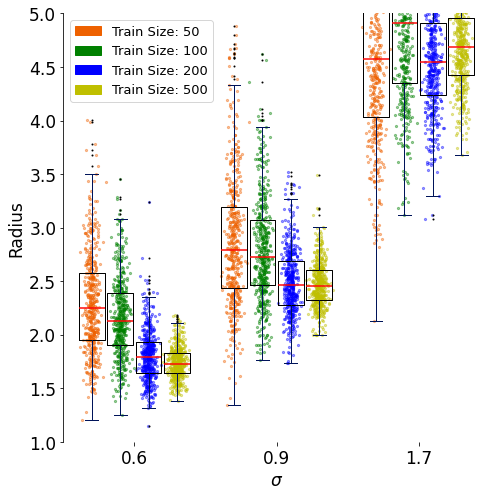

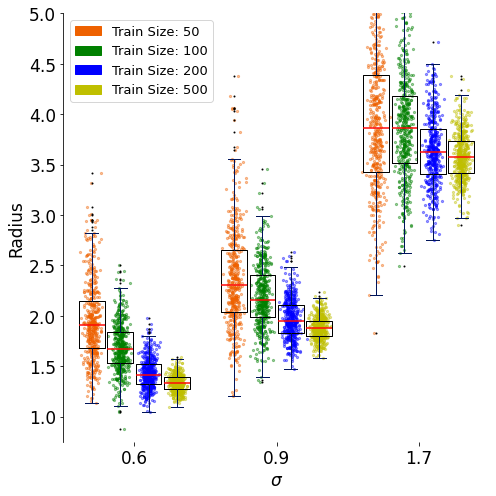

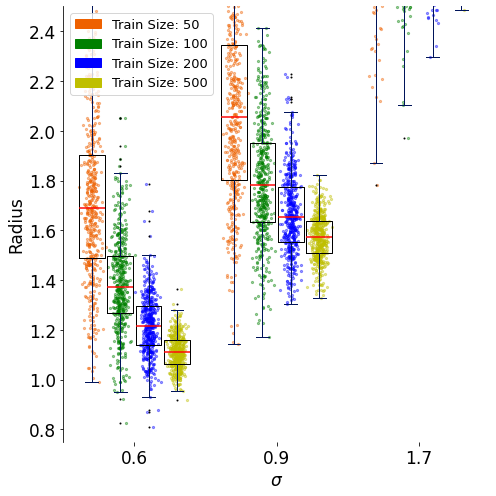

In [35]:
for data, alpha_level in zip(
    [ii_coverage_df_conformal_alpha_01, ii_coverage_df_conformal_alpha_05, ii_coverage_df_conformal_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_coverage_df_conformal_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_coverage_df_conformal_alpha_05
    else:
        coverage_df = ii_coverage_df_conformal_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    sigmas = sorted(coverage_df['sigma'].unique())

    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['sigma'] == sigma) & (coverage_df['train_size'] == N), 'quantiles']
            for N in train_sizes]
        for sigma in sigmas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for a given train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False) 

            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j], s = 5)


    sns.despine(bottom=True) # removes right and top axis lines

    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(sigmas))],
        labels=sigmas
    )
    ax.set_xlim(0, len(sigmas) * (len(train_sizes) + 1))
    if alpha_level == 0.01:
        ax.set_ylim(1, 5)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 5)
    else:
        ax.set_ylim(0.75, 5)


    ax.set_xlabel(r'$\sigma$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)

    legend_handles = [
        mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
        for j in range(len(train_sizes))
    ]
    ax.legend(handles=legend_handles, loc='upper left', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'conf_euc_radius_vs_sigma_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

0.6


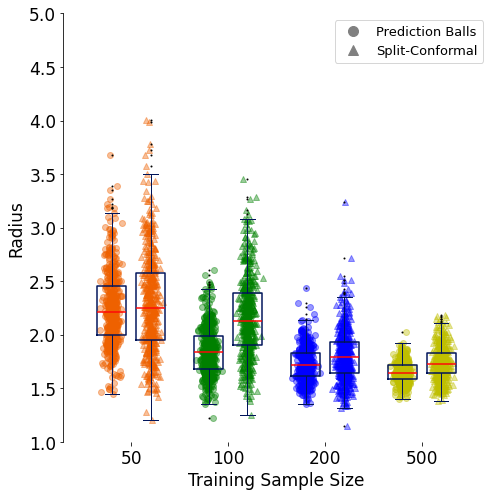

0.6


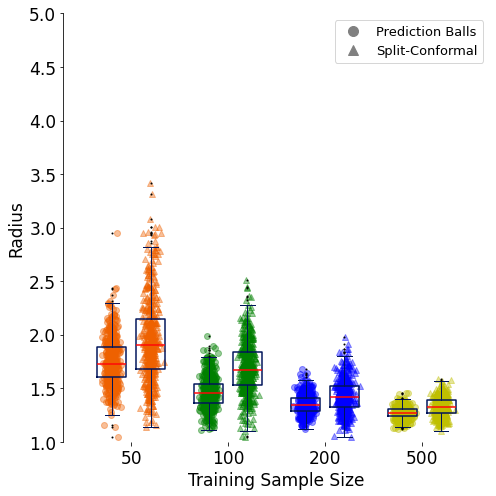

0.6


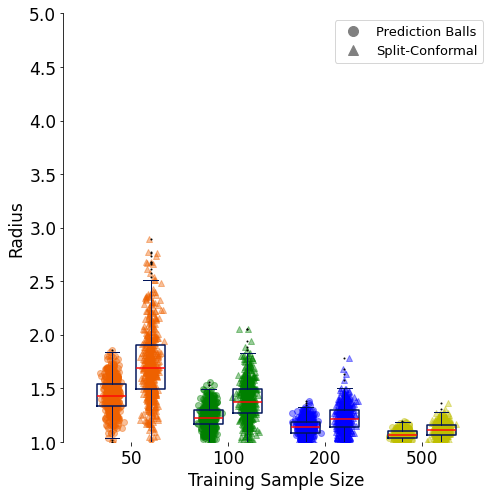

0.9


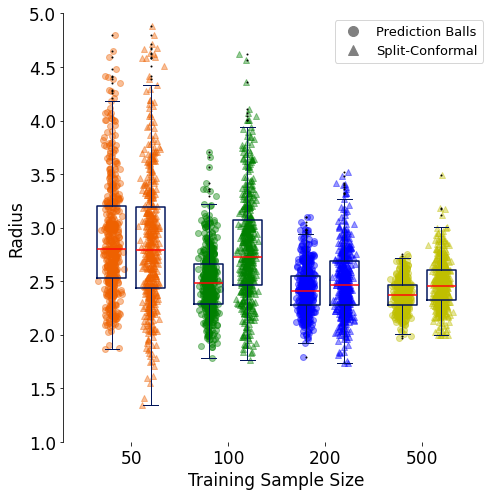

0.9


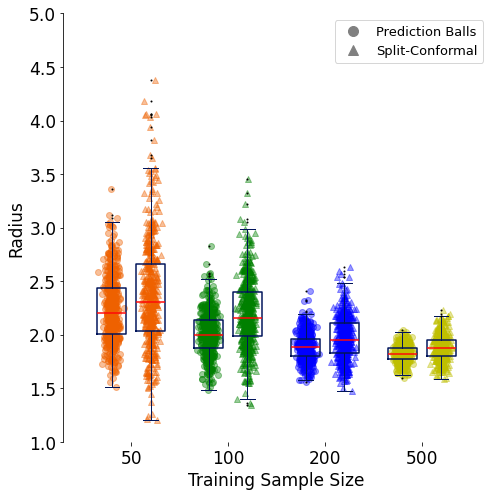

0.9


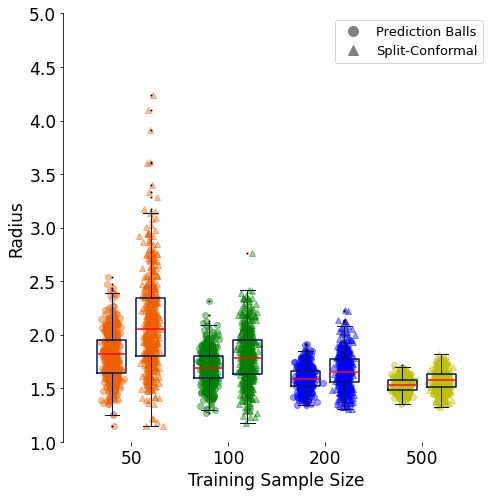

1.7


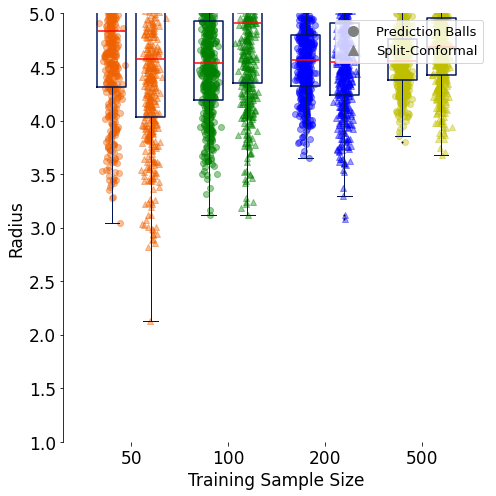

1.7


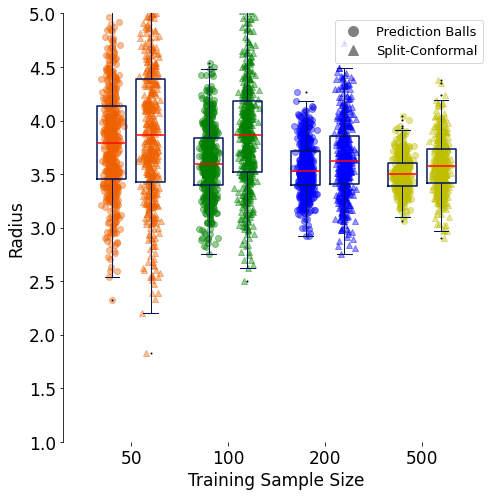

1.7


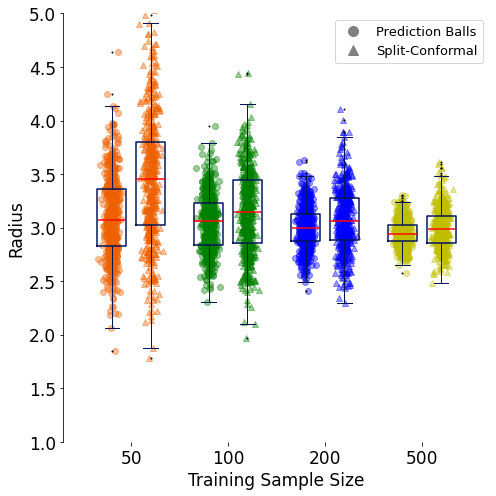

In [54]:
def compare_pb_sc_radius(pb_data_list, sc_data_list, alpha_levels, sigmas, train_sizes, save_path):
    """
    Compare Prediction Ball (PB) and Split-Conformal (SC) radius across different sigma and alpha values.

    Parameters:
        pb_data_list (list): List of DataFrames containing PB radius for each alpha level.
        sc_data_list (list): List of DataFrames containing SC radius for each alpha level.
        alpha_levels (list): List of significance levels (e.g., [0.01, 0.05, 0.1]).
        sigmas (list): List of sigma values to consider.
        train_sizes (list): List of training sample sizes.
        save_path (str): Path to save the generated plots.
    """
    
    ##### Set style options #####
    boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
    flierprops = dict(marker='o', markersize=1, linestyle='none')
    whiskerprops = dict(color='#00145A')
    capprops = dict(color='#00145A')
    medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

    # Iterate over sigma values
    for sigma in sigmas:
        for pb_data, sc_data, alpha in zip(pb_data_list, sc_data_list, alpha_levels):
            fig = plt.figure(facecolor="white", figsize=(7, 7))
            ax = fig.add_subplot(111)

            # Prepare boxplot data
            pb_boxplot_data = [
                pb_data.loc[(pb_data['sigma'] == str(sigma)) & (pb_data['train_size'] == N), 'OOB_quantile']
                for N in train_sizes
            ]
            sc_boxplot_data = [
                sc_data.loc[(sc_data['sigma'] == str(sigma)) & (sc_data['train_size'] == N), 'quantiles']
                for N in train_sizes
            ]

            # Set positions for PB and SC boxplots
            positions_pb = np.array(range(len(train_sizes))) - 0.2
            positions_sc = np.array(range(len(train_sizes))) + 0.2
            print(sigma)
            # Boxplots for PB and SC
            ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
                       boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                       flierprops=flierprops, medianprops=medianprops, showmeans=False)
            
            ax.boxplot(sc_boxplot_data, positions=positions_sc, widths=0.3, notch=False, 
                       boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                       flierprops=flierprops, medianprops=medianprops, showmeans=False)

            # Scatter plot
            palette = ['#ee6100', 'g', 'b', 'y']  # Colors for each N

            for i, N in enumerate(train_sizes):
                xs_pb = np.random.normal(positions_pb[i], 0.04, len(pb_boxplot_data[i]))
                xs_sc = np.random.normal(positions_sc[i], 0.04, len(sc_boxplot_data[i]))
                ax.scatter(xs_pb, pb_boxplot_data[i], alpha=0.4, color=palette[i], label='Prediction Balls' if i == 0 else "")
                ax.scatter(xs_sc, sc_boxplot_data[i], alpha=0.4, color=palette[i], marker='^', label='Split-Conformal' if i == 0 else "")

            sns.despine(bottom=True)  # Remove right and top axis lines

            ax.set_xticks(range(len(train_sizes)))
            ax.set_xticklabels([str(N) for N in train_sizes], fontsize=17)

            ax.set_xlabel('Training Sample Size', fontsize=17)
            ax.set_ylabel('Radius', fontsize=17)
            ax.tick_params(labelsize=17)
            ax.grid(False)

            # Set y-limits based on alpha
            if sigma == 0.1 and alpha == 0.01:
                ax.set_ylim(1, 5)
            elif sigma==0.1 and alpha == 0.05:
                ax.set_ylim(1, 5)
            elif sigma==0.1 and alpha == 0.1:
                ax.set_ylim(1, 5)
            elif sigma == 0.5 and alpha == 0.01:
                ax.set_ylim(1, 5)
            elif sigma==0.5 and alpha == 0.05:
                ax.set_ylim(1, 5)
            else:
                ax.set_ylim(1, 5)
        
            # Legend
            legend_handles = [
                mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction Balls'),
                mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-Conformal')
            ]
            ax.legend(handles=legend_handles, loc='upper right', fontsize=13)

            fig.tight_layout()
            filename = os.path.join(save_path, f'simulations_euc/pb_vs_conf_radius_vs_sigma_{sigma}_alpha_{str(alpha)[2:]}.pdf')
            fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
            plt.show()

compare_pb_sc_radius(
    pb_data_list= [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1],
    sc_data_list= [ii_coverage_df_conformal_alpha_01, ii_coverage_df_conformal_alpha_05, ii_coverage_df_conformal_alpha_1],
    alpha_levels=[0.01, 0.05, 0.1],
    sigmas=[0.6, 0.9, 1.7],  # Modify as needed
    train_sizes=[50, 100, 200, 500],
    save_path=os.getcwd()  # Change to desired directory
)

# TYPE III

In [206]:
MC = 500
n_estimations = 100

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario_iii = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

conf_diccionario_iii = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

np.random.seed(1)
# Obtain n_estimations estimations of Type III coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for sigma in [0.6, 0.9, 1.7]:
    pb_coverage_df_sigma = pb_coverage_df[pb_coverage_df['sigma'] == str(sigma)]
    conformal_coverage_df_sigma = conformal_coverage_df[conformal_coverage_df['sigma'] == str(sigma)]

    if sigma == 0.6:
        true_sigma = 1/np.sqrt(3)
    elif sigma == 0.9:
        true_sigma = np.sqrt(3)/2
    elif sigma == 1.7:
        true_sigma = np.sqrt(3)
    else:
        raise ValueError("Sigma value not found.")
        
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = pb_coverage_df_sigma[pb_coverage_df_sigma['train_size'] == N]
        conf_coverage_df_N = conformal_coverage_df_sigma[conformal_coverage_df_sigma['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)
            conf_yesno = np.zeros(3)

            new_X_design = np.repeat(0, MC * n_predictors).reshape(MC, n_predictors)
            new_X_design, new_ys = simulate_data(sigma = true_sigma, X_design = new_X_design, betas = betas)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
            conf_lns = conf_coverage_df_N.sample(n=MC, replace=False)

            i = 0
            for j, pb_ln in pb_lns.iterrows():
                conf_ln = conf_lns.iloc[i]
                # Retrieve the data           
                new_y = new_ys[i]
                new_X = new_X_design[0,:].reshape(1, n_predictors)
                pb_new_pred = pb_ln['forest'].predict(new_X)
                conf_new_pred = conf_ln['forest'].predict(new_X)
                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, np.abs(pb_new_pred - new_y) <= pb_ln['OOB_quantile']))
                conf_yesno = np.vstack((conf_yesno, np.abs(conf_new_pred - new_y) <= conf_ln['quantiles']))
                i += 1

            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC
            conf_cov[estimation, :] = conf_yesno[1:,:].sum(axis=0) / MC

        pb_diccionario_iii['sigma_'+str(sigma)][str(N)] = np.copy(pb_cov)
        conf_diccionario_iii['sigma_'+str(sigma)][str(N)] = np.copy(conf_cov)

In [77]:
#for sigma in [0.6, 0.9, 1.7]:    
#    for N in [50, 100, 200, 500]:
#        print(f"sigma = {sigma}, N = {N}, mean of Type III coverage estimates: ", np.mean(pb_diccionario_iii['sigma_'+str(sigma)][str(N)], axis = 0)) 
#        print(f"sigma = {sigma}, N = {N}, standard deviation of Type III coverage estimates: ", np.sqrt(np.var(pb_diccionario_iii['sigma_'+str(sigma)][str(N)], axis = 0))  )   

In [78]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
pb_df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
pb_df_iii

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.6   50            99.33 (0.43)  97.14 (0.90)  93.41 (1.95)
      100           98.77 (0.78)  95.50 (0.94)  91.26 (1.67)
      200           98.45 (0.80)  94.59 (1.49)  89.55 (1.79)
      500           98.54 (0.62)  94.56 (1.19)  89.22 (1.75)
0.9   50            98.82 (0.60)  95.82 (1.11)  90.96 (1.67)
      100           98.21 (0.80)  95.07 (1.31)  90.37 (1.72)
      200           98.75 (0.69)  94.56 (1.34)  89.97 (1.91)
      500           98.59 (0.72)  93.95 (1.46)  88.83 (2.31)
1.7   50            98.67 (0.66)  95.47 (1.23)  89.98 (1.80)
      100           97.98 (0.90)  94.69 (1.33)  90.30 (1.85)
      200           98.69 (0.74)  95.07 (1.61)  90.32 (1.65)
      500           98.94 (0.58)  95.42 (1.28)  91.17 (1.81)

In [79]:
# Apply formatting to all cells
pb_latex_iii= pb_df_iii.applymap(format_cell)

pb_latex_iii = pb_latex_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type I error coverage for differentvalues of $\sigma$ and sample sizes', label='tab:typeIerrorcoverage')
print(pb_latex_iii)

\begin{table}
\caption{Type I error coverage for differentvalues of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.6}} & \textbf{50} & 99.33 (0.43) & 97.14 (0.90) & 93.41 (1.95) \\
\textbf{} & \textbf{100} & 98.77 (0.78) & 95.50 (0.94) & 91.26 (1.67) \\
\textbf{} & \textbf{200} & 98.45 (0.80) & 94.59 (1.49) & 89.55 (1.79) \\
\textbf{} & \textbf{500} & 98.54 (0.62) & 94.56 (1.19) & 89.22 (1.75) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.9}} & \textbf{50} & 98.82 (0.60) & 95.82 (1.11) & 90.96 (1.67) \\
\textbf{} & \textbf{100} & 98.21 (0.80) & 95.07 (1.31) & 90.37 (1.72) \\
\textbf{} & \textbf{200} & 98.75 (0.69) & 94.56 (1.34) & 89.97 (1.91) \\
\textbf{} & \textbf{500} & 98.59 (0.72) & 93.95 (1.46) & 88.83 (2.31) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.7}} & \textbf{50} & 98.67 (0.66) & 95.47 (1.23) & 89.98 (1.80) \\
\tex

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56630/2774234259.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pb_latex_iii= pb_df_iii.applymap(format_cell)


In [80]:
#for sigma in [0.6, 0.9, 1.7]:    
#    for N in [50, 100, 200, 500]:
#        print(f"sigma = {sigma}, N = {N}, mean of Type III coverage estimates: ", np.mean(conf_diccionario_iii['sigma_'+str(sigma)][str(N)], axis = 0)) 
#        print(f"sigma = {sigma}, N = {N}, standard deviation of Type III coverage estimates: ", np.sqrt(np.var(conf_diccionario_iii['sigma_'+str(sigma)][str(N)], axis = 0))  )   

In [81]:
# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        stds = np.sqrt(np.var(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
conf_df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
conf_df_iii

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.6   50            98.83 (0.56)  97.52 (0.81)  95.58 (0.84)
      100           99.33 (0.50)  97.31 (0.96)  93.18 (1.51)
      200           98.40 (0.75)  95.02 (1.45)  90.54 (2.16)
      500           98.85 (0.77)  94.96 (1.17)  89.84 (2.11)
0.9   50            98.26 (0.79)  95.79 (1.09)  93.31 (1.22)
      100           98.66 (0.63)  95.79 (1.24)  90.80 (1.35)
      200           98.42 (0.84)  94.72 (1.26)  90.11 (1.51)
      500           98.53 (0.73)  94.35 (1.43)  89.44 (1.90)
1.7   50            97.66 (0.81)  95.31 (1.11)  92.27 (1.12)
      100           98.67 (0.68)  95.42 (1.30)  90.21 (2.00)
      200           98.37 (0.77)  95.01 (1.44)  90.26 (2.25)
      500           99.12 (0.61)  95.97 (1.07)  91.07 (1.53)

In [82]:
# Apply formatting to all cells
conf_latex_iii= conf_df_iii.applymap(format_cell)

conf_latex_iii = conf_latex_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type III error coverage for different values of $\sigma$ and sample sizes', label='tab:typeIerrorcoverage')
print(conf_latex_iii)

\begin{table}
\caption{Type III error coverage for different values of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.6}} & \textbf{50} & 98.83 (0.56) & 97.52 (0.81) & 95.58 (0.84) \\
\textbf{} & \textbf{100} & 99.33 (0.50) & 97.31 (0.96) & 93.18 (1.51) \\
\textbf{} & \textbf{200} & 98.40 (0.75) & 95.02 (1.45) & 90.54 (2.16) \\
\textbf{} & \textbf{500} & 98.85 (0.77) & 94.96 (1.17) & 89.84 (2.11) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.9}} & \textbf{50} & 98.26 (0.79) & 95.79 (1.09) & 93.31 (1.22) \\
\textbf{} & \textbf{100} & 98.66 (0.63) & 95.79 (1.24) & 90.80 (1.35) \\
\textbf{} & \textbf{200} & 98.42 (0.84) & 94.72 (1.26) & 90.11 (1.51) \\
\textbf{} & \textbf{500} & 98.53 (0.73) & 94.35 (1.43) & 89.44 (1.90) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.7}} & \textbf{50} & 97.66 (0.81) & 95.31 (1.11) & 92.27 (1.12) \\
\

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56630/683290145.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  conf_latex_iii= conf_df_iii.applymap(format_cell)


Combined

In [210]:
import pandas as pd
import numpy as np

def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        row = []
        means_pb = np.mean(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        stds_pb = np.sqrt(np.var(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        
        means_conf = np.mean(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        stds_conf = np.sqrt(np.var(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        
        # Format as "mean (std)"
        formatted_values_pb = [f"{100*means_pb[i]:.2f} ({100*stds_pb[i]:.2f})" for i in range(3)]
        formatted_values_conf = [f"{100*means_conf[i]:.2f} ({100*stds_conf[i]:.2f})" for i in range(3)]
        
        row.extend(formatted_values_pb + formatted_values_conf)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=[f"$\sigma$", f"$n$"])
col_index = pd.MultiIndex.from_product(
    [["Prediction Balls", "Split-Conformal"], ["0.01", "0.05", "0.1"]],
    names=["", ""]
)

# Create the DataFrame
df_combined = pd.DataFrame(rows, index=row_index, columns=col_index)

# Apply formatting
df_combined = df_combined.applymap(format_cell)

# Convert to LaTeX
latex_combined = df_combined.to_latex(index=True, multirow=True, multicolumn=True, 
                                      multicolumn_format='c', bold_rows=False, 
                                      float_format="%.3f", 
                                      caption='Comparison of Type III error coverage for prediction balls and SC regions', 
                                      label='tab:euc_typeIII_PB_SC')

print(latex_combined)

\begin{table}
\caption{Comparison of Type III error coverage for prediction balls and SC regions}
\label{tab:euc_typeIII_PB_SC}
\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{3}{c}{Prediction Balls} & \multicolumn{3}{c}{Split-Conformal} \\
 &  & 0.01 & 0.05 & 0.1 & 0.01 & 0.05 & 0.1 \\
$\sigma$ & $n$ &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{0.6} & 50 & 99.56 (0.31) & 97.66 (0.69) & 94.14 (0.99) & 99.18 (0.36) & 97.78 (0.70) & 95.92 (0.84) \\
 & 100 & 98.91 (0.47) & 95.99 (0.81) & 91.85 (1.14) & 99.40 (0.28) & 97.43 (0.61) & 93.65 (0.89) \\
 & 200 & 98.81 (0.52) & 95.18 (0.97) & 90.65 (1.29) & 98.50 (0.55) & 95.10 (0.93) & 90.89 (1.20) \\
 & 500 & 98.83 (0.49) & 94.88 (1.08) & 89.93 (1.41) & 98.93 (0.44) & 95.36 (0.85) & 90.58 (1.30) \\
\cline{1-8}
\multirow[t]{4}{*}{0.9} & 50 & 99.02 (0.43) & 96.49 (0.82) & 91.52 (1.28) & 98.54 (0.53) & 96.25 (0.75) & 94.13 (0.92) \\
 & 100 & 98.43 (0.52) & 95.30 (0.86) & 90.97 (1.25) & 98.87 (0.52) & 96.32 (0.82) & 91.78 (1.22) \\
 & 20

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56630/2429355871.py:43: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_combined = df_combined.applymap(format_cell)


In [211]:
df_combined

Prediction Balls                             Split-Conformal  \
                         0.01          0.05           0.1            0.01   
$\sigma$ $n$                                                                
0.6      50      99.56 (0.31)  97.66 (0.69)  94.14 (0.99)    99.18 (0.36)   
         100     98.91 (0.47)  95.99 (0.81)  91.85 (1.14)    99.40 (0.28)   
         200     98.81 (0.52)  95.18 (0.97)  90.65 (1.29)    98.50 (0.55)   
         500     98.83 (0.49)  94.88 (1.08)  89.93 (1.41)    98.93 (0.44)   
0.9      50      99.02 (0.43)  96.49 (0.82)  91.52 (1.28)    98.54 (0.53)   
         100     98.43 (0.52)  95.30 (0.86)  90.97 (1.25)    98.87 (0.52)   
         200     98.53 (0.52)  94.56 (0.95)  89.74 (1.32)    98.44 (0.46)   
         500     98.74 (0.52)  94.61 (1.05)  89.55 (1.55)    98.82 (0.48)   
1.7      50      98.44 (0.59)  94.95 (1.04)  89.57 (1.33)    97.58 (0.70)   
         100     98.27 (0.60)  94.48 (1.06)  89.82 (1.47)    98.63 (0.44)   
         200     98.71 (0.46)  94.77 (0.95)  90.07 (1.14)    98.30 (0.64)   
         500     98.84 (0.42)  94.84 (0.93)  89.94 (1.30)    98.87 (0.48)   

                                          
                      0.05           0.1  
$\sigma$ $n$                              
0.6      50   97.78 (0.70)  95.92 (0.84)  
         100  97.43 (0.61)  93.65 (0.89)  
         200  95.10 (0.93)  90.89 (1.20)  
         500  95.36 (0.85)  90.58 (1.30)  
0.9      50   96.25 (0.75)  94.13 (0.92)  
         100  96.32 (0.82)  91.78 (1.22)  
         200  94.93 (0.86)  90.48 (1.26)  
         500  94.81 (1.02)  89.44 (1.38)  
1.7      50   94.70 (0.97)  91.53 (1.22)  
         100  95.48 (0.98)  90.24 (1.27)  
         200  94.78 (1.08)  90.03 (1.44)  
         500  94.93 (0.95)  90.01 (1.40)

$X=(1, 1, 1)$

In [218]:
MC = 500
n_estimations = 100

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario_iii = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

conf_diccionario_iii = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

np.random.seed(1)
# Obtain n_estimations estimations of Type III coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for sigma in [0.6, 0.9, 1.7]:
    pb_coverage_df_sigma = pb_coverage_df[pb_coverage_df['sigma'] == str(sigma)]
    conformal_coverage_df_sigma = conformal_coverage_df[conformal_coverage_df['sigma'] == str(sigma)]

    if sigma == 0.6:
        true_sigma = 1/np.sqrt(3)
    elif sigma == 0.9:
        true_sigma = np.sqrt(3)/2
    elif sigma == 1.7:
        true_sigma = np.sqrt(3)
    else:
        raise ValueError("Sigma value not found.")
        
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = pb_coverage_df_sigma[pb_coverage_df_sigma['train_size'] == N]
        conf_coverage_df_N = conformal_coverage_df_sigma[conformal_coverage_df_sigma['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)
            conf_yesno = np.zeros(3)

            new_X_design = np.repeat(1, MC * n_predictors).reshape(MC, n_predictors)
            new_X_design, new_ys = simulate_data(sigma = true_sigma, X_design = new_X_design, betas = betas)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
            conf_lns = conf_coverage_df_N.sample(n=MC, replace=False)

            i = 0
            for j, pb_ln in pb_lns.iterrows():
                conf_ln = conf_lns.iloc[i]
                # Retrieve the data           
                new_y = new_ys[i]
                new_X = new_X_design[0,:].reshape(1, n_predictors)
                pb_new_pred = pb_ln['forest'].predict(new_X)
                conf_new_pred = conf_ln['forest'].predict(new_X)
                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, np.abs(pb_new_pred - new_y) <= pb_ln['OOB_quantile']))
                conf_yesno = np.vstack((conf_yesno, np.abs(conf_new_pred - new_y) <= conf_ln['quantiles']))
                i += 1

            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC
            conf_cov[estimation, :] = conf_yesno[1:,:].sum(axis=0) / MC

        pb_diccionario_iii['sigma_'+str(sigma)][str(N)] = np.copy(pb_cov)
        conf_diccionario_iii['sigma_'+str(sigma)][str(N)] = np.copy(conf_cov)

In [219]:
import pandas as pd
import numpy as np

def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        row = []
        means_pb = np.mean(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        stds_pb = np.sqrt(np.var(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        
        means_conf = np.mean(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        stds_conf = np.sqrt(np.var(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        
        # Format as "mean (std)"
        formatted_values_pb = [f"{100*means_pb[i]:.2f} ({100*stds_pb[i]:.2f})" for i in range(3)]
        formatted_values_conf = [f"{100*means_conf[i]:.2f} ({100*stds_conf[i]:.2f})" for i in range(3)]
        
        row.extend(formatted_values_pb + formatted_values_conf)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=[f"$\sigma$", f"$n$"])
col_index = pd.MultiIndex.from_product(
    [["Prediction Balls", "Split-Conformal"], ["0.01", "0.05", "0.1"]],
    names=["", ""]
)

# Create the DataFrame
df_combined = pd.DataFrame(rows, index=row_index, columns=col_index)

# Apply formatting
df_combined = df_combined.applymap(format_cell)

# Convert to LaTeX
latex_combined = df_combined.to_latex(index=True, multirow=True, multicolumn=True, 
                                      multicolumn_format='c', bold_rows=False, 
                                      float_format="%.3f", 
                                      caption='Comparison of Type III error coverage for prediction balls and SC regions', 
                                      label='tab:euc_typeIII_PB_SC')

print(latex_combined)
print(df_combined)

\begin{table}
\caption{Comparison of Type III error coverage for prediction balls and SC regions}
\label{tab:euc_typeIII_PB_SC}
\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{3}{c}{Prediction Balls} & \multicolumn{3}{c}{Split-Conformal} \\
 &  & 0.01 & 0.05 & 0.1 & 0.01 & 0.05 & 0.1 \\
$\sigma$ & $n$ &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{0.6} & 50 & 99.49 (0.32) & 97.41 (0.66) & 93.75 (0.96) & 98.61 (0.47) & 96.69 (0.66) & 94.12 (0.89) \\
 & 100 & 98.92 (0.44) & 96.36 (0.77) & 92.40 (1.24) & 99.18 (0.36) & 96.64 (0.75) & 92.24 (1.12) \\
 & 200 & 99.12 (0.38) & 96.27 (0.74) & 92.13 (1.10) & 98.96 (0.47) & 95.89 (0.87) & 91.92 (1.18) \\
 & 500 & 99.15 (0.39) & 95.90 (1.00) & 91.39 (1.45) & 99.24 (0.37) & 96.15 (0.78) & 91.54 (1.24) \\
\cline{1-8}
\multirow[t]{4}{*}{0.9} & 50 & 98.80 (0.47) & 95.92 (0.82) & 90.85 (1.40) & 97.52 (0.62) & 94.43 (0.88) & 91.49 (1.05) \\
 & 100 & 98.52 (0.53) & 95.33 (0.90) & 91.06 (1.21) & 98.79 (0.45) & 95.73 (0.87) & 90.60 (1.31) \\
 & 20

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56630/3605389423.py:43: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_combined = df_combined.applymap(format_cell)


$X=(-1, -1, -1)$

In [220]:
MC = 500
n_estimations = 100

zeros_init = np.zeros(shape = (n_estimations, 3))
pb_cov = np.zeros(shape = (n_estimations, 3))
conf_cov = np.zeros(shape = (n_estimations, 3))

pb_diccionario_iii = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

conf_diccionario_iii = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

np.random.seed(1)
# Obtain n_estimations estimations of Type III coverage error for each distance and N, to calculate the mean of the estimations and the sample variance
for sigma in [0.6, 0.9, 1.7]:
    pb_coverage_df_sigma = pb_coverage_df[pb_coverage_df['sigma'] == str(sigma)]
    conformal_coverage_df_sigma = conformal_coverage_df[conformal_coverage_df['sigma'] == str(sigma)]

    if sigma == 0.6:
        true_sigma = 1/np.sqrt(3)
    elif sigma == 0.9:
        true_sigma = np.sqrt(3)/2
    elif sigma == 1.7:
        true_sigma = np.sqrt(3)
    else:
        raise ValueError("Sigma value not found.")
        
    for N in [50, 100, 200, 500]:
        # Select the size of the training set
        pb_coverage_df_N = pb_coverage_df_sigma[pb_coverage_df_sigma['train_size'] == N]
        conf_coverage_df_N = conformal_coverage_df_sigma[conformal_coverage_df_sigma['train_size'] == N]
        for estimation in range(n_estimations):
            pb_yesno = np.zeros(3)
            conf_yesno = np.zeros(3)

            new_X_design = np.repeat(-1, MC * n_predictors).reshape(MC, n_predictors)
            new_X_design, new_ys = simulate_data(sigma = true_sigma, X_design = new_X_design, betas = betas)
            pb_lns = pb_coverage_df_N.sample(n=MC, replace=False)
            conf_lns = conf_coverage_df_N.sample(n=MC, replace=False)

            i = 0
            for j, pb_ln in pb_lns.iterrows():
                conf_ln = conf_lns.iloc[i]
                # Retrieve the data           
                new_y = new_ys[i]
                new_X = new_X_design[0,:].reshape(1, n_predictors)
                pb_new_pred = pb_ln['forest'].predict(new_X)
                conf_new_pred = conf_ln['forest'].predict(new_X)
                # Store the selected values
                pb_yesno = np.vstack((pb_yesno, np.abs(pb_new_pred - new_y) <= pb_ln['OOB_quantile']))
                conf_yesno = np.vstack((conf_yesno, np.abs(conf_new_pred - new_y) <= conf_ln['quantiles']))
                i += 1

            pb_cov[estimation, :] = pb_yesno[1:,:].sum(axis=0) / MC
            conf_cov[estimation, :] = conf_yesno[1:,:].sum(axis=0) / MC

        pb_diccionario_iii['sigma_'+str(sigma)][str(N)] = np.copy(pb_cov)
        conf_diccionario_iii['sigma_'+str(sigma)][str(N)] = np.copy(conf_cov)

In [223]:
import pandas as pd
import numpy as np

def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Prepare data for the DataFrame
rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        row = []
        means_pb = np.mean(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        stds_pb = np.sqrt(np.var(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        
        means_conf = np.mean(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        stds_conf = np.sqrt(np.var(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        
        # Format as "mean (std)"
        formatted_values_pb = [f"{100*means_pb[i]:.2f} ({100*stds_pb[i]:.2f})" for i in range(3)]
        formatted_values_conf = [f"{100*means_conf[i]:.2f} ({100*stds_conf[i]:.2f})" for i in range(3)]
        
        row.extend(formatted_values_pb + formatted_values_conf)
        rows.append(row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=[f"$\sigma$", f"$n$"])
col_index = pd.MultiIndex.from_product(
    [["Prediction Balls", "Split-Conformal"], ["0.01", "0.05", "0.1"]],
    names=["", ""]
)

# Create the DataFrame
df_combined = pd.DataFrame(rows, index=row_index, columns=col_index)

# Apply formatting
df_combined = df_combined.applymap(format_cell)

# Convert to LaTeX
latex_combined = df_combined.to_latex(index=True, multirow=True, multicolumn=True, 
                                      multicolumn_format='c', bold_rows=False, 
                                      float_format="%.3f", 
                                      caption='Comparison of Type III error coverage for prediction balls and SC regions', 
                                      label='tab:euc_typeIII_PB_SC')

print(latex_combined)

\begin{table}
\caption{Comparison of Type III error coverage for prediction balls and SC regions}
\label{tab:euc_typeIII_PB_SC}
\begin{tabular}{llllllll}
\toprule
 &  & \multicolumn{3}{c}{Prediction Balls} & \multicolumn{3}{c}{Split-Conformal} \\
 &  & 0.01 & 0.05 & 0.1 & 0.01 & 0.05 & 0.1 \\
$\sigma$ & $n$ &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{0.6} & 50 & 99.40 (0.37) & 97.07 (0.71) & 93.38 (1.00) & 97.86 (0.58) & 95.67 (0.88) & 92.73 (1.10) \\
 & 100 & 99.06 (0.48) & 96.37 (0.91) & 92.49 (1.13) & 99.14 (0.38) & 96.73 (0.63) & 92.43 (1.03) \\
 & 200 & 98.96 (0.47) & 95.78 (0.84) & 91.50 (1.17) & 98.89 (0.52) & 95.94 (0.93) & 91.95 (1.19) \\
 & 500 & 99.13 (0.43) & 95.86 (1.05) & 91.37 (1.36) & 99.27 (0.42) & 96.40 (0.79) & 91.81 (1.26) \\
\cline{1-8}
\multirow[t]{4}{*}{0.9} & 50 & 98.85 (0.46) & 95.93 (0.76) & 90.72 (1.14) & 97.74 (0.68) & 94.74 (0.88) & 91.89 (0.96) \\
 & 100 & 98.72 (0.45) & 95.67 (0.94) & 91.56 (1.23) & 98.84 (0.51) & 96.10 (0.79) & 91.30 (1.19) \\
 & 20

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56630/2429355871.py:43: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_combined = df_combined.applymap(format_cell)


In [222]:
df_combined

Prediction Balls                             Split-Conformal  \
                         0.01          0.05           0.1            0.01   
$\sigma$ $n$                                                                
0.6      50      99.40 (0.37)  97.07 (0.71)  93.38 (1.00)    97.86 (0.58)   
         100     99.06 (0.48)  96.37 (0.91)  92.49 (1.13)    99.14 (0.38)   
         200     98.96 (0.47)  95.78 (0.84)  91.50 (1.17)    98.89 (0.52)   
         500     99.13 (0.43)  95.86 (1.05)  91.37 (1.36)    99.27 (0.42)   
0.9      50      98.85 (0.46)  95.93 (0.76)  90.72 (1.14)    97.74 (0.68)   
         100     98.72 (0.45)  95.67 (0.94)  91.56 (1.23)    98.84 (0.51)   
         200     98.79 (0.43)  95.23 (0.97)  90.62 (1.28)    98.35 (0.56)   
         500     98.96 (0.44)  95.32 (0.97)  90.39 (1.28)    99.05 (0.44)   
1.7      50      98.19 (0.59)  94.41 (1.00)  88.57 (1.44)    97.04 (0.80)   
         100     98.06 (0.54)  94.24 (0.92)  89.29 (1.29)    98.21 (0.57)   
         200     98.81 (0.46)  94.88 (0.95)  90.13 (1.27)    98.30 (0.50)   
         500     98.86 (0.46)  95.05 (0.91)  90.26 (1.25)    98.92 (0.42)   

                                          
                      0.05           0.1  
$\sigma$ $n$                              
0.6      50   95.67 (0.88)  92.73 (1.10)  
         100  96.73 (0.63)  92.43 (1.03)  
         200  95.94 (0.93)  91.95 (1.19)  
         500  96.40 (0.79)  91.81 (1.26)  
0.9      50   94.74 (0.88)  91.89 (0.96)  
         100  96.10 (0.79)  91.30 (1.19)  
         200  94.77 (1.00)  90.33 (1.26)  
         500  95.31 (0.92)  90.60 (1.39)  
1.7      50   93.68 (1.00)  90.22 (1.22)  
         100  94.58 (0.96)  88.74 (1.26)  
         200  94.52 (0.94)  89.71 (1.26)  
         500  95.14 (1.03)  90.23 (1.30)

# Type IV

Primero, hacemos todo con $(-0.5, -0.5, -0.5)$.

In [196]:
np.random.seed(1000)
pb_coverage_df['IV_coverage'] = [[0, 0, 0] for _ in range(len(pb_coverage_df))]
MC = 500
for i, ln in pb_coverage_df.iterrows():
    #Calculate coverage for every dataset L_n (Type IV):
    sigma = float(ln['sigma'])
    new_pred = np.array([ln['forest'].predict(np.repeat(-1, n_predictors).reshape(1, n_predictors))])
    new_pred = np.tile(new_pred, (MC, 1))
    new_y = simulate_data(X_design = np.repeat(-1, MC * n_predictors).reshape(MC, n_predictors), sigma = sigma, betas = betas)[1]
    pb_coverage_df.at[i, 'IV_coverage'] = np.sum(np.abs(new_pred - new_y).reshape(-1,1) <= np.tile(ln['OOB_quantile'], (MC, 1)), axis = 0) / MC

In [197]:
np.random.seed(1000)
conformal_coverage_df['IV_coverage'] = [[0, 0, 0] for _ in range(len(conformal_coverage_df))]
MC = 500
for i, ln in conformal_coverage_df.iterrows():
    #Calculate coverage for every dataset L_n (Type IV):
    sigma = float(ln['sigma'])
    new_pred = np.array([ln['forest'].predict(np.repeat(-1, n_predictors).reshape(1, n_predictors))])
    new_pred = np.tile(new_pred, (MC, 1))
    new_y = simulate_data(X_design = np.repeat(-1, MC * n_predictors).reshape(MC, n_predictors), sigma = sigma, betas = betas)[1]
    conformal_coverage_df.at[i, 'IV_coverage'] = np.sum(np.abs(new_pred - new_y).reshape(-1,1) <= np.tile(ln['quantiles'], (MC, 1)), axis = 0) / MC

In [74]:
iv_pb_coverage_df_alpha_01 = pb_coverage_df.copy()
iv_pb_coverage_df_alpha_05 = pb_coverage_df.copy()
iv_pb_coverage_df_alpha_1 = pb_coverage_df.copy()
iv_pb_coverage_df_alpha_01['IV_coverage'] = pb_coverage_df['IV_coverage'].apply(lambda x: x[0])
iv_pb_coverage_df_alpha_05['IV_coverage'] = pb_coverage_df['IV_coverage'].apply(lambda x: x[1])
iv_pb_coverage_df_alpha_1['IV_coverage'] = pb_coverage_df['IV_coverage'].apply(lambda x: x[2])

iv_pb_coverage_df_alpha_01.head()
iv_pb_coverage_df_alpha_05.head()
iv_pb_coverage_df_alpha_1.head()

iv_coverage_df_conf_alpha_01 = conformal_coverage_df.copy()
iv_coverage_df_conf_alpha_05 = conformal_coverage_df.copy()
iv_coverage_df_conf_alpha_1 = conformal_coverage_df.copy()

iv_coverage_df_conf_alpha_01['IV_coverage'] = conformal_coverage_df['IV_coverage'].apply(lambda x: x[0])
iv_coverage_df_conf_alpha_05['IV_coverage'] = conformal_coverage_df['IV_coverage'].apply(lambda x: x[1])
iv_coverage_df_conf_alpha_1['IV_coverage'] = conformal_coverage_df['IV_coverage'].apply(lambda x: x[2])

iv_coverage_df_conf_alpha_1.head()
iv_coverage_df_conf_alpha_05.head()
iv_coverage_df_conf_alpha_01.head()

,sample_index,train_size,sigma,forest,time,x_test_data,quantiles,II_coverage,IV_coverage
0,339,50,1.7,"(DecisionTreeRegressor(max_features=2, random_...",5.365662,"[[-0.09309465359866426, -0.4078574187756428, 0...","[3.8090170967543164, 3.5047659422440427, 3.003...","[0.964, 0.946, 0.904]",0.952
1,488,500,0.9,"(DecisionTreeRegressor(max_features=3, min_sam...",5.300507,"[[0.5413650944561323, 0.5532088779882177, 0.34...","[2.7180059204834945, 1.8473518040587442, 1.622...","[0.99, 0.926, 0.888]",0.996
2,27,500,0.6,"(DecisionTreeRegressor(max_features=2, random_...",5.540146,"[[1.2927667942165173, 1.3095441450899923, -1.4...","[1.7665605078309818, 1.2053814183438494, 1.040...","[0.99, 0.914, 0.87]",0.994
3,82,100,0.6,"(DecisionTreeRegressor(max_features=3, random_...",4.633087,"[[1.177998795430376, -1.3117707714790274, 1.32...","[2.1684101812687073, 1.5653649499417075, 1.128...","[0.986, 0.908, 0.8]",0.998
4,455,200,0.9,"(DecisionTreeRegressor(max_features=1, random_...",5.517519,"[[1.3510438509862233, -1.354302096775215, 1.33...","[2.248093859882377, 2.0139712507980345, 1.3461...","[0.962, 0.95, 0.822]",0.982


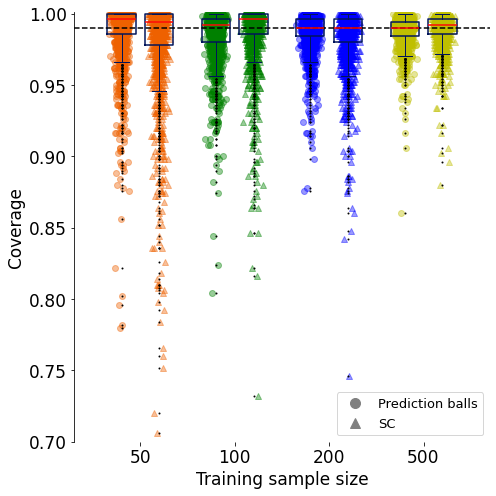

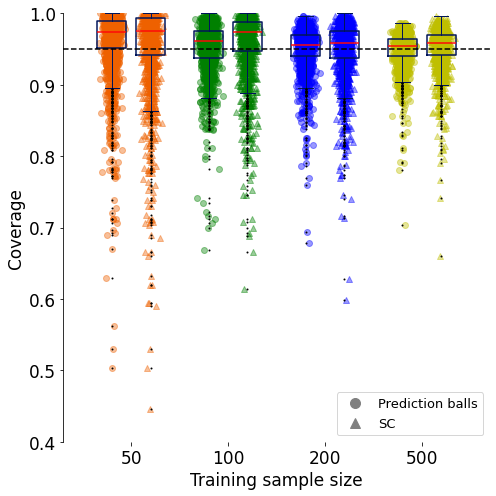

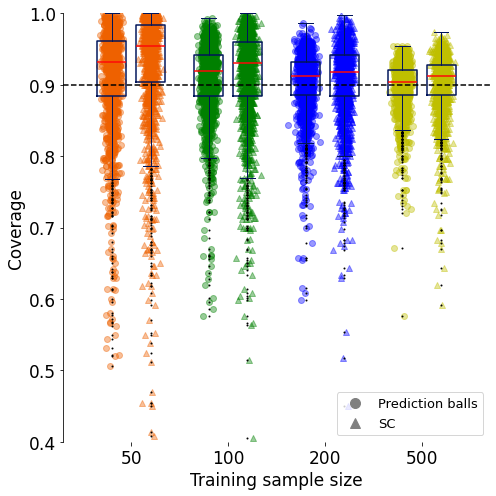

In [224]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for pb_data, conf_data, alpha_level in zip(
    [iv_pb_coverage_df_alpha_01, iv_pb_coverage_df_alpha_05, iv_pb_coverage_df_alpha_1], 
    [iv_coverage_df_conf_alpha_01, iv_coverage_df_conf_alpha_05, iv_coverage_df_conf_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_boxplot_data = [pb_data[pb_data['train_size'] == size]['IV_coverage'].values for size in train_sizes]
    conf_boxplot_data = [conf_data[conf_data['train_size'] == size]['IV_coverage'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_pb = np.array(range(len(train_sizes))) - 0.2
    positions_conf = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
               boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
               flierprops=flierprops, medianprops=medianprops, showmeans=False)
    
    ax.boxplot(conf_boxplot_data, positions=positions_conf, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot for individual points
    palette_euc = ['#ee6100', 'g', 'b', 'y']
    palette_conf = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_pb = np.random.normal(positions_pb[i], 0.04, len(pb_boxplot_data[i]))
        xs_conf = np.random.normal(positions_conf[i], 0.04, len(conf_boxplot_data[i]))

        ax.scatter(xs_pb, pb_boxplot_data[i], alpha=0.4, color=palette_euc[i], label='Prediction balls')
        ax.scatter(xs_conf, conf_boxplot_data[i], alpha=0.4, color=palette_conf[i], marker='^', label='SC')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)
    if alpha_level == 0.01:
        ax.set_ylim(0.7, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.4, 1)
    else:
        ax.set_ylim(0.4, 1)
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Legend
    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='SC')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_vs_IV_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

# Times

In [7]:
pb_coverage_df[pb_coverage_df['train_size'] == 500]['time'].mean()

6.244499226252238

In [94]:
import pandas as pd
import numpy as np

def compute_summary(df, method_name):
    grouped = df.groupby("train_size")["time"].agg(["mean", "std"])
    grouped = grouped  # Scale values
    return {size: f"{row['mean']:.2f} ({row['std']:.2f})" for size, row in grouped.iterrows()}

# Compute summaries for both methods
euc_summary = compute_summary(pb_coverage_df, "Prediction Balls")
sc_summary = compute_summary(conformal_coverage_df, "SC")

# Get unique train sizes
train_sizes = sorted(set(pb_coverage_df["train_size"]) | set(conformal_coverage_df["train_size"]))

# Construct DataFrame for LaTeX output
data = {
    size: [euc_summary.get(size, "-"), sc_summary.get(size, "-")] 
    for size in train_sizes
}
df_latex = pd.DataFrame(data, index=["Prediction Balls", "SC"])

# Generate LaTeX table
latex = df_latex.to_latex(
    index=True, column_format="l" + "c" * len(train_sizes),
    caption='Computation times for Prediction Balls and SC methods',
    label='tab:computation_times')

print(latex)

\begin{table}
\caption{Computation times for Prediction Balls and SC methods}
\label{tab:computation_times}
\begin{tabular}{lcccc}
\toprule
 & 50 & 100 & 200 & 500 \\
\midrule
Prediction Balls & 7.14 (36.44) & 7.68 (37.72) & 6.61 (24.44) & 8.03 (26.38) \\
SC & 4.56 (0.35) & 4.68 (0.35) & 4.90 (0.35) & 5.49 (0.37) \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_56630/2309609881.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("train_size")["time"].agg(["mean", "std"])


In [8]:
import pandas as pd
import numpy as np

def compute_summary(df, method_name):
    grouped = df.groupby("train_size")["time"].agg(["mean", "std"])
    grouped = grouped  # Scale values
    return {size: f"{row['mean']:.2f} ({row['std']:.2f})" for size, row in grouped.iterrows()}

# Compute summaries for both methods
euc_summary = compute_summary(pb_coverage_df, "Prediction Balls")
sc_summary = compute_summary(conformal_coverage_df, "SC")

# Get unique train sizes
train_sizes = sorted(set(pb_coverage_df["train_size"]) | set(conformal_coverage_df["train_size"]))

# Construct DataFrame for LaTeX output
data = {
    size: [euc_summary.get(size, "-"), sc_summary.get(size, "-")] 
    for size in train_sizes
}
df_latex = pd.DataFrame(data, index=["Prediction Balls", "SC"])

# Generate LaTeX table
latex = df_latex.to_latex(
    index=True, column_format="l" + "c" * len(train_sizes),
    caption='Computation times for Prediction Balls and SC methods',
    label='tab:computation_times')

print(latex)

\begin{table}
\caption{Computation times for Prediction Balls and SC methods}
\label{tab:computation_times}
\begin{tabular}{lcccc}
\toprule
 & 50 & 100 & 200 & 500 \\
\midrule
Prediction Balls & 4.59 (0.21) & 4.81 (0.21) & 5.23 (0.20) & 6.24 (0.22) \\
SC & 4.39 (0.14) & 4.52 (0.14) & 4.74 (0.13) & 5.33 (0.14) \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_81544/2309609881.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("train_size")["time"].agg(["mean", "std"])


In [10]:
4.59 / 50 /np.log(50)

0.023466119670723425

In [11]:
4.81 / 100 /np.log(100)

0.010444782289773205

In [12]:
5.23 / 200 /np.log(200)

0.0049355291861342895